# 01. Carregamento, Exploração e Preparação dos Dados

Este notebook realiza o carregamento, a análise exploratória (EDA) e a preparação dos dados do dataset **AI4I 2020 Predictive Maintenance** (UCI Machine Learning Repository) para modelagem. O objetivo é prever falhas de máquinas industriais (`Machine failure = 0 ou 1`) a partir de leituras de sensores operacionais.

**Etapas deste notebook:**
1. Carregamento e inspeção do dataset.
2. Validação de consistência do rótulo de falha.
3. Análise Exploratória de Dados (EDA) com visualizações.
4. Seleção de features por correlação e tratamento de variáveis categóricas.
5. Divisão treino/teste estratificada e normalização.
6. Exportação dos conjuntos finais.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importar funções do pacote src
sys.path.insert(0, os.path.abspath('..'))
from src.carregamento_dados import carregar_dataset, validar_rotulo_falha
from src.preprocessamento import preparar_features

# Configurações
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
SEED = 42

DADOS_BRUTOS = os.path.abspath('../dados_brutos')
DADOS_TRATADOS = os.path.abspath('../dados_tratados')



---
## 1. Carregamento e Inspeção do Dataset

O dataset AI4I 2020 Predictive Maintenance contém 10.000 registros de operação de máquinas industriais, com 5 variáveis de sensores (temperatura do ar, temperatura do processo, velocidade rotacional, torque e desgaste da ferramenta), 1 variável categórica (tipo de produto: L, M ou H), e o rótulo binário de falha.

As colunas `TWF`, `HDF`, `PWF`, `OSF` e `RNF` representam os **submodos de falha** que compõem o rótulo `Machine failure`. Essas colunas **não podem ser usadas como features** pois causariam vazamento de dados (data leakage) — elas são a decomposição do próprio alvo.

In [2]:
df = carregar_dataset(os.path.join(DADOS_BRUTOS, 'ai4i2020.csv'))

print(f'Shape: {df.shape}')
print()
df.info()
print()
df.describe()

Shape: (10000, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


---
## 2. Validação de Consistência do Rótulo

Antes de prosseguir, é fundamental verificar se o rótulo `Machine failure` é consistente com os submodos de falha: espera-se que `Machine failure == 1` sempre que pelo menos um dos submodos (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) também seja 1. Qualquer inconsistência indicaria problemas na geração dos dados.

In [3]:
validacao = validar_rotulo_falha(df)

print(f'Total de registros: {validacao["total"]}')
print(f'Machine failure == 1: {validacao["falhas"]}')
print(f'Pelo menos 1 submodo == 1: {validacao["algum_submodo"]}')
print(f'Linhas consistentes: {validacao["consistentes"]}')
print(f'Linhas INCONSISTENTES: {validacao["inconsistentes"]}')

if validacao['inconsistentes'] > 0:
    print(f'\n⚠️ {validacao["inconsistentes"]} linhas inconsistentes encontradas:')
    print(validacao['df_inconsistentes'][['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']].head(10))
else:
    print('\n✅ Rótulo 100% consistente com os submodos.')

Total de registros: 10000
Machine failure == 1: 339
Pelo menos 1 submodo == 1: 348
Linhas consistentes: 9973
Linhas INCONSISTENTES: 27

⚠️ 27 linhas inconsistentes encontradas:
      Machine failure  TWF  HDF  PWF  OSF  RNF
1221                0    0    0    0    0    1
1302                0    0    0    0    0    1
1437                1    0    0    0    0    0
1748                0    0    0    0    0    1
2072                0    0    0    0    0    1
2559                0    0    0    0    0    1
2749                1    0    0    0    0    0
3065                0    0    0    0    0    1
3452                0    0    0    0    0    1
4044                1    0    0    0    0    0


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição da Variável Alvo (Machine failure)

O dataset apresenta um **desbalanceamento severo**: apenas ~3,4% dos registros correspondem a falhas. Isso implica que a acurácia bruta é uma métrica enganosa (um modelo que sempre prevê "sem falha" já teria ~96,6% de acurácia). As métricas de foco devem ser Precisão, Recall e F1-Score da classe minoritária (falha).

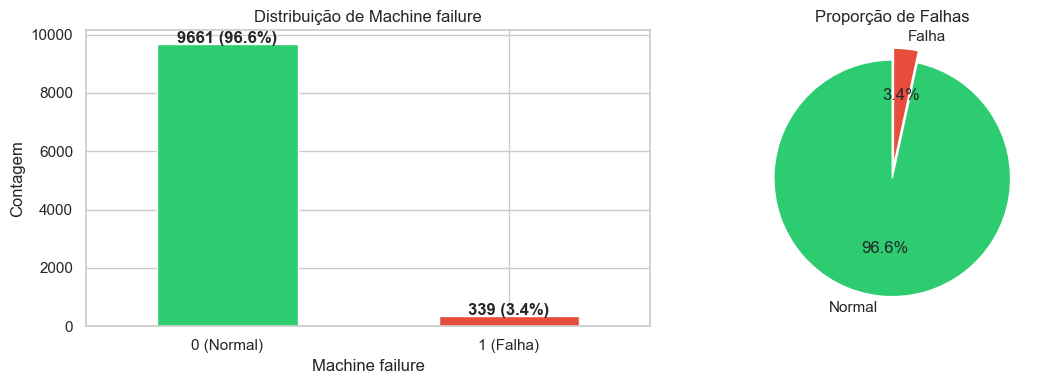

Taxa de falha: 3.39%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem
contagem = df['Machine failure'].value_counts()
colors = ['#2ecc71', '#e74c3c']
contagem.plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribuição de Machine failure')
axes[0].set_xlabel('Machine failure')
axes[0].set_ylabel('Contagem')
axes[0].set_xticklabels(['0 (Normal)', '1 (Falha)'], rotation=0)
for i, v in enumerate(contagem):
    axes[0].text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pizza
contagem.plot.pie(ax=axes[1], autopct='%1.1f%%', colors=colors, startangle=90,
                  labels=['Normal', 'Falha'], explode=[0, 0.1])
axes[1].set_ylabel('')
axes[1].set_title('Proporção de Falhas')

plt.tight_layout()
plt.show()

print(f'Taxa de falha: {df["Machine failure"].mean()*100:.2f}%')

### 3.2 Distribuição dos Submodos de Falha

Cada submodo de falha (TWF = Tool Wear Failure, HDF = Heat Dissipation Failure, PWF = Power Failure, OSF = Overstrain Failure, RNF = Random Failure) representa um mecanismo diferente de falha. Analisamos a frequência de cada um para entender quais são os modos de falha mais comuns.

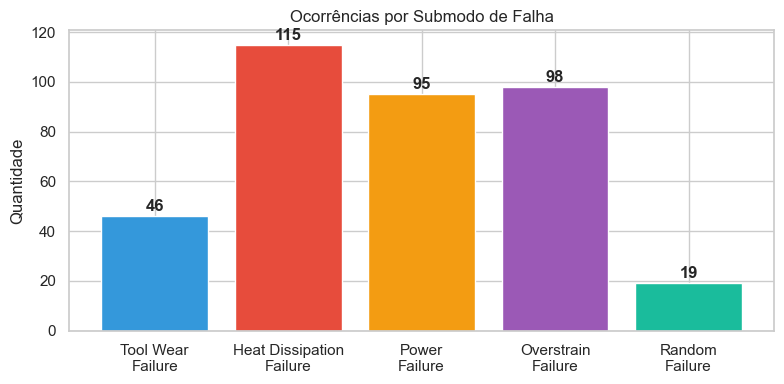

In [5]:
submodos = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
submodo_labels = {
    'TWF': 'Tool Wear\nFailure',
    'HDF': 'Heat Dissipation\nFailure',
    'PWF': 'Power\nFailure',
    'OSF': 'Overstrain\nFailure',
    'RNF': 'Random\nFailure'
}
contagens_sub = df[submodos].sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([submodo_labels[s] for s in submodos], contagens_sub.values,
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c'],
              edgecolor='white')
ax.set_title('Ocorrências por Submodo de Falha')
ax.set_ylabel('Quantidade')
for bar, val in zip(bars, contagens_sub.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Tipo de Produto e Taxa de Falha

A variável `Type` indica a qualidade do produto: **L** (Low), **M** (Medium), **H** (High). Analisamos se a taxa de falha varia entre os tipos de produto.

Tabela Cruzada: Type x Machine failure
      Normal (0)  Falha (1)  Total
Type                              
H            982         21   1003
L           5765        235   6000
M           2914         83   2997
All         9661        339  10000

Taxa de falha por tipo de produto (%):
  H: 2.09%
  L: 3.92%
  M: 2.77%


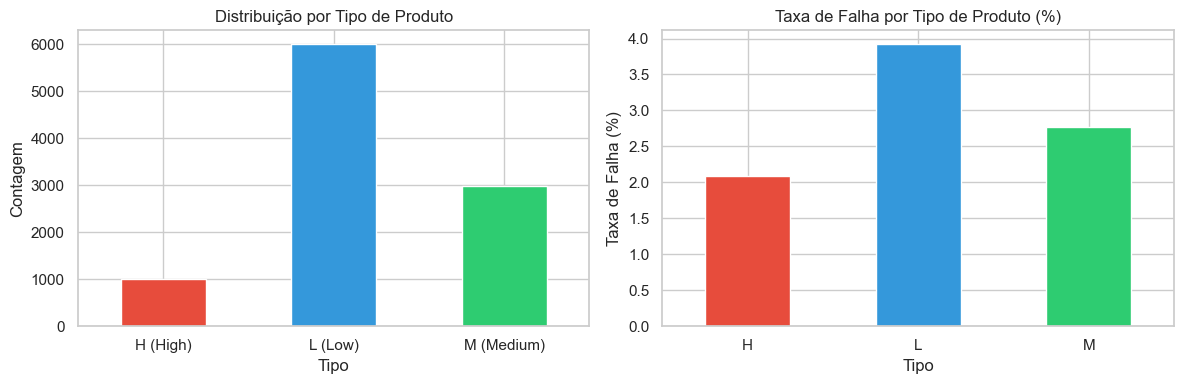

In [6]:
# Tabela cruzada
ct = pd.crosstab(df['Type'], df['Machine failure'], margins=True)
ct.columns = ['Normal (0)', 'Falha (1)', 'Total']
print('Tabela Cruzada: Type x Machine failure')
print(ct)
print()

# Taxa de falha por tipo
taxa_falha = df.groupby('Type')['Machine failure'].mean() * 100
print('Taxa de falha por tipo de produto (%):')  
for tipo, taxa in taxa_falha.items():
    print(f'  {tipo}: {taxa:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição de Type
df['Type'].value_counts().sort_index().plot.bar(ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'],
                                                 edgecolor='white')
axes[0].set_title('Distribuição por Tipo de Produto')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Contagem')
axes[0].set_xticklabels(['H (High)', 'L (Low)', 'M (Medium)'], rotation=0)

# Taxa de falha por tipo
taxa_falha.sort_index().plot.bar(ax=axes[1], color=['#e74c3c', '#3498db', '#2ecc71'],
                                  edgecolor='white')
axes[1].set_title('Taxa de Falha por Tipo de Produto (%)')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Taxa de Falha (%)')
axes[1].set_xticklabels(['H', 'L', 'M'], rotation=0)

plt.tight_layout()
plt.show()

### 3.4 Distribuição das Variáveis Numéricas (Sensores)

Analisamos a distribuição de cada variável numérica capturada pelos sensores da máquina.

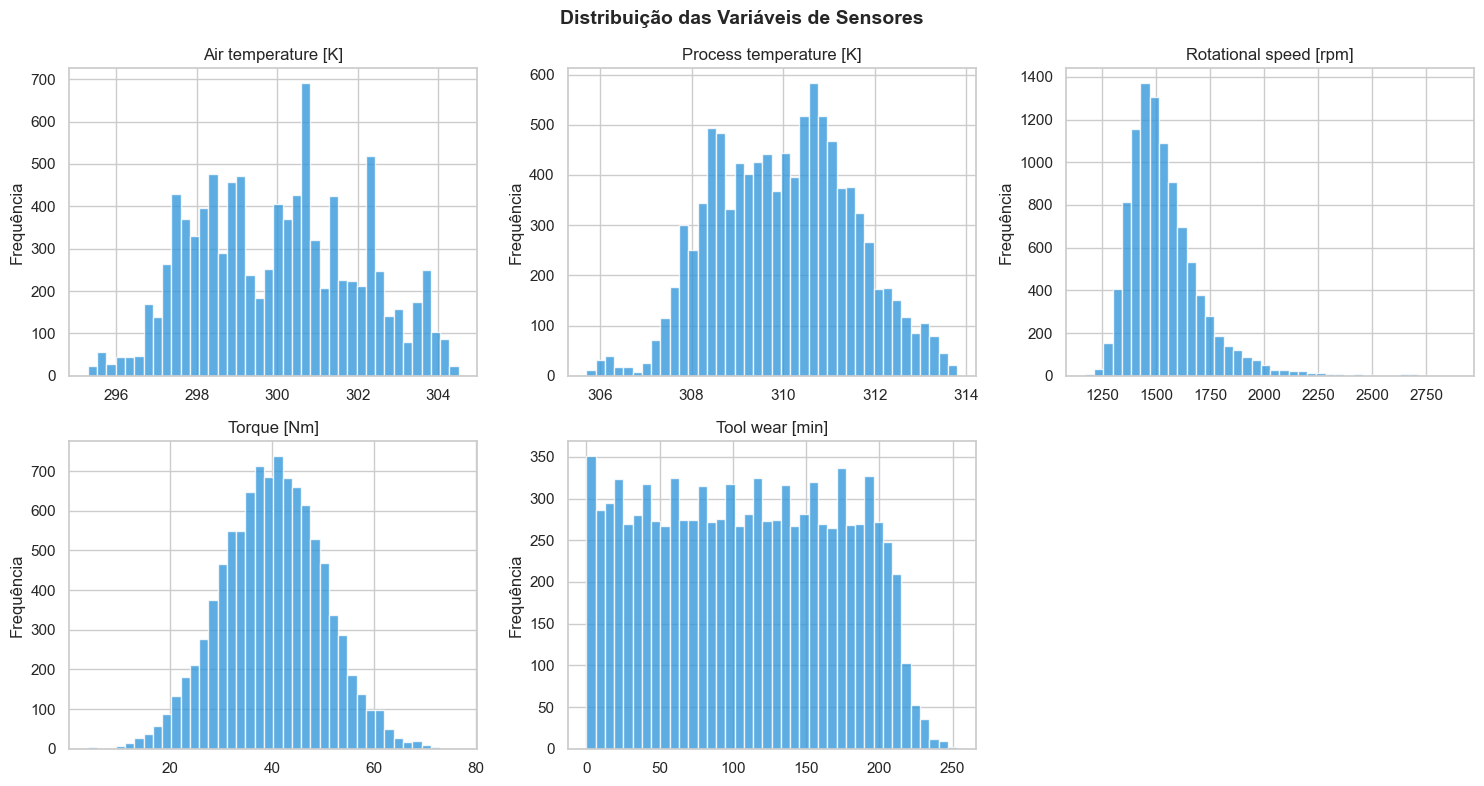

In [7]:
vars_numericas = ['Air temperature [K]', 'Process temperature [K]',
                  'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    axes[i].hist(df[col], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequência')

axes[5].set_visible(False)
plt.suptitle('Distribuição das Variáveis de Sensores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Comparação das Variáveis por Classe (Normal vs Falha)

Para verificar se existe separação visual entre as classes, comparamos a distribuição de cada variável numérica nos registros de operação normal (`Machine failure = 0`) e nos de falha (`Machine failure = 1`). Espera-se que máquinas que falharam apresentem, por exemplo, temperaturas mais altas, torques mais extremos ou maior desgaste de ferramenta.

/var/folders/bk/nf9vrk757zn986tflnzbjbmm0000gn/T/ipykernel_93064/1926004995.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal (0)', 'Falha (1)'])
/var/folders/bk/nf9vrk757zn986tflnzbjbmm0000gn/T/ipykernel_93064/1926004995.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal (0)', 'Falha (1)'])
/var/folders/bk/nf9vrk757zn986tflnzbjbmm0000gn/T/ipykernel_93064/1926004995.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Normal (0)', 'Falha (1)'])
/var/folders/bk/nf9vrk757zn986tflnzbjbmm0000gn/T/ipykernel_93064/1926004995.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLoca

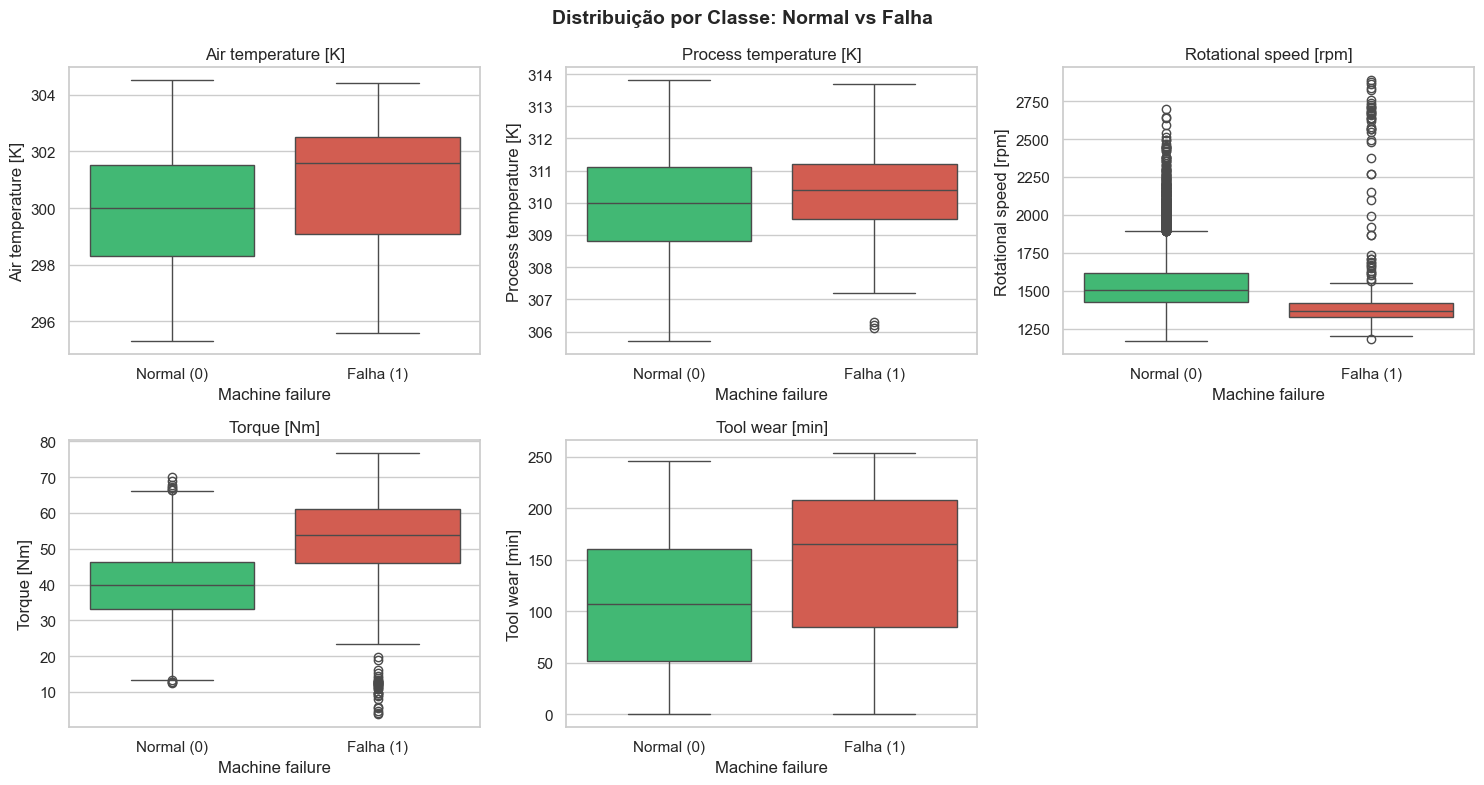

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(vars_numericas):
    sns.boxplot(data=df, x='Machine failure', y=col, ax=axes[i],
                palette={0: '#2ecc71', 1: '#e74c3c'}, hue='Machine failure', legend=False)
    axes[i].set_title(col)
    axes[i].set_xticklabels(['Normal (0)', 'Falha (1)'])

axes[5].set_visible(False)
plt.suptitle('Distribuição por Classe: Normal vs Falha', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Correlação e Composição Final das Features

Calculamos a correlação de Pearson entre cada variável e o alvo `Machine failure` para entender os efeitos individuais.

> **Nota**: Diferente de modelos mais simples, as falhas na manutenção preditiva industrial dependem de **combinações** e **regras** entre os sensores (ex: falha de dissipação térmica depende da diferença de temperaturas simultaneamente com a velocidade de rotação). Por isso, **nenhuma variável numérica de sensor será descartada com base no limiar individual de correlação**, pois elas são estruturalmente relevantes na detecção combinada.

**Colunas excluídas da modelagem** (não são features válidas):
- `UDI` e `Product ID`: identificadores, sem valor preditivo.
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: submodos de falha — são componentes do rótulo, usá-los causaria data leakage.


In [9]:
# Preparar DataFrame para correlação (sem colunas proibidas)
colunas_excluir_corr = ['UDI', 'Product ID', 'Type', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_corr = df.drop(columns=colunas_excluir_corr)

corr_matrix = df_corr.corr(numeric_only=True)
correlacoes = corr_matrix['Machine failure'].drop('Machine failure', errors='ignore')
correlacoes = correlacoes.reindex(correlacoes.abs().sort_values(ascending=False).index)

print('Correlação de cada feature com Machine failure:')
print('-' * 55)
for col, val in correlacoes.items():
    print(f'  {col:<35} {val:+.4f}')

# Mantendo TODAS as variáveis numéricas de sensor
selecionadas = list(correlacoes.index)
print(f'\nFeatures mantidas: {len(selecionadas)}')


Correlação de cada feature com Machine failure:
-------------------------------------------------------
  Torque [Nm]                         +0.1913
  Tool wear [min]                     +0.1054
  Air temperature [K]                 +0.0826
  Rotational speed [rpm]              -0.0442
  Process temperature [K]             +0.0359

Features mantidas: 5


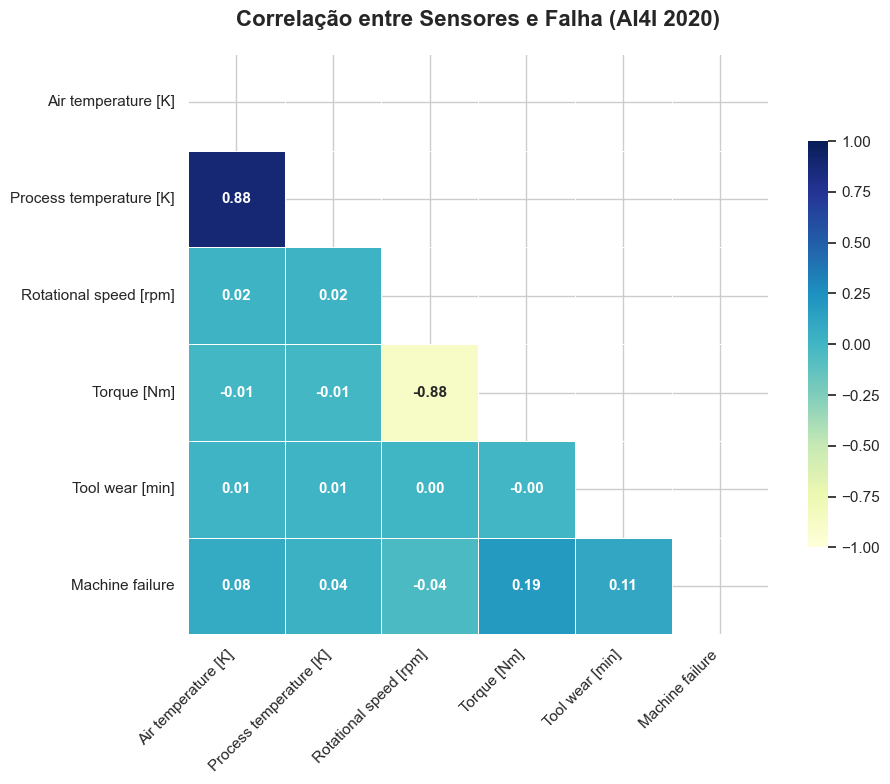

In [56]:
# Matriz de Correlação aprimorada
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


sns.heatmap(corr_matrix, mask=mask, cmap="YlGnBu", vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .7}, 
            annot=True, fmt='.2f', annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title('Correlação entre Sensores e Falha (AI4I 2020)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontweight='medium')
ax.set_yticklabels(ax.get_yticklabels(), fontweight='medium')

plt.tight_layout()
plt.show()


### 4.1 One-Hot Encoding e Composição Final das Features

A variável `Type` (L, M, H) é categórica e precisa ser convertida em variáveis binárias (one-hot encoding). Para evitar a **dummy variable trap** (redundância perfeita entre as dummies de uma variável com $k$ categorias), removemos a primeira categoria (`H`), ficando com `Type_L` e `Type_M` — saber essas duas automaticamente determina se é `H`.

In [11]:
# Preparar features: one-hot encoding + remoção de colunas proibidas
colunas_excluir = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']
df_features = preparar_features(df, colunas_excluir, coluna_categorica='Type', drop_first_dummy=True)

print(f'Colunas do df_features ({len(df_features.columns)}):')
for col in df_features.columns:
    print(f'  {col}')

# Lista final de features: numéricas selecionadas + dummies de Type
features_dummies = [c for c in df_features.columns if c.startswith('Type_')]
features_finais = selecionadas + features_dummies
print(f'\nFeatures finais ({len(features_finais)}):')
for i, f in enumerate(features_finais, 1):
    print(f'  {i}. {f}')

Colunas do df_features (7):
  Air temperature [K]
  Process temperature [K]
  Rotational speed [rpm]
  Torque [Nm]
  Tool wear [min]
  Type_L
  Type_M

Features finais (7):
  1. Torque [Nm]
  2. Tool wear [min]
  3. Air temperature [K]
  4. Rotational speed [rpm]
  5. Process temperature [K]
  6. Type_L
  7. Type_M


---
## 5. Verificação de Valores Faltantes

In [57]:
faltantes = df_features[features_finais].isnull().sum()
total_faltantes = faltantes.sum()

if total_faltantes == 0:
    print('Nenhum valor faltante nas features selecionadas.')
else:
    print(f'{total_faltantes} valores faltantes encontrados:')
    print(faltantes[faltantes > 0])

Nenhum valor faltante nas features selecionadas.


---
## 6. Divisão Treino/Teste (Estratificada)

Dado o **desbalanceamento severo** (~3,4% de falhas), é importante usar `stratify=y` na divisão treino/teste. Sem isso, o conjunto de teste poderia ficar com proporções muito diferentes do conjunto original, ou até mesmo sem nenhum exemplo de falha, invalidando completamente a avaliação do modelo.

Reservamos 20% dos dados para teste e 80% para treino, mantendo a proporção original de classes em ambos.

In [13]:
X = df_features[features_finais].values
y = df['Machine failure'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (8000, 7)
X_test:  (2000, 7)
y_train: (8000,)
y_test:  (2000,)


---
## 7. Normalização com StandardScaler

As variáveis numéricas de sensores possuem escalas muito diferentes (temperatura em Kelvin ~300, velocidade em rpm ~1500, torque em Nm ~40). A normalização garante que todas as features contribuam de forma equilibrada para o aprendizado da rede neural.

O `StandardScaler` é ajustado **apenas nos dados de treino** (`fit_transform`) e aplicado no teste (`transform`), evitando qualquer vazamento de informação do teste para o treino.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter para DataFrame para salvar com nomes de colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_finais)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_finais)

print('Estatísticas após normalização (treino):')
print(X_train_scaled.describe().loc[['mean', 'std']].round(4))

Estatísticas após normalização (treino):
      Torque [Nm]  Tool wear [min]  Air temperature [K]  \
mean      -0.0000          -0.0000              -0.0000   
std        1.0001           1.0001               1.0001   

      Rotational speed [rpm]  Process temperature [K]  Type_L  Type_M  
mean                  0.0000                  -0.0000 -0.0000  0.0000  
std                   1.0001                   1.0001  1.0001  1.0001  


---
## 8. Resumo Final: N, p e Proporção de Classes

In [58]:
N_treino = X_train_scaled.shape[0]
p_features = X_train_scaled.shape[1]

print(f'=== DIMENSÕES FINAIS ===')
print(f'N (amostras de treino): {N_treino}')
print(f'p (número de features): {p_features}')
print(f'Amostras de teste: {X_test_scaled.shape[0]}')
print()
print(f'--- Proporção de classes ---')
print(f'y_train: Normal={int((y_train==0).sum())} ({(y_train==0).mean()*100:.1f}%), '
      f'Falha={int((y_train==1).sum())} ({(y_train==1).mean()*100:.1f}%)')
print(f'y_test:  Normal={int((y_test==0).sum())} ({(y_test==0).mean()*100:.1f}%), '
      f'Falha={int((y_test==1).sum())} ({(y_test==1).mean()*100:.1f}%)')
print(f'\nStratify manteve a proporção original em ambos os conjuntos.')
print(f'\nEssas informações serão usadas para o cálculo da dimensão VC da rede neural.')

=== DIMENSÕES FINAIS ===
N (amostras de treino): 8000
p (número de features): 7
Amostras de teste: 2000

--- Proporção de classes ---
y_train: Normal=7729 (96.6%), Falha=271 (3.4%)
y_test:  Normal=1932 (96.6%), Falha=68 (3.4%)

Stratify manteve a proporção original em ambos os conjuntos.

Essas informações serão usadas para o cálculo da dimensão VC da rede neural.


---
## 9. Exportação dos Conjuntos Finais

In [16]:
X_train_scaled.to_csv(os.path.join(DADOS_TRATADOS, 'X_train.csv'), index=False)
X_test_scaled.to_csv(os.path.join(DADOS_TRATADOS, 'X_test.csv'), index=False)
pd.DataFrame(y_train, columns=['Machine_failure']).to_csv(
    os.path.join(DADOS_TRATADOS, 'y_train.csv'), index=False)
pd.DataFrame(y_test, columns=['Machine_failure']).to_csv(
    os.path.join(DADOS_TRATADOS, 'y_test.csv'), index=False)

print(f'Arquivos salvos em {DADOS_TRATADOS}:')
for f in ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']:
    size = os.path.getsize(os.path.join(DADOS_TRATADOS, f)) / 1024
    print(f'  {f}: {size:.1f} KB')

Arquivos salvos em /Users/anne/Documents/UFPB/manutencao-preditiva/dados_tratados:
  X_train.csv: 1073.1 KB
  X_test.csv: 268.4 KB
  y_train.csv: 15.6 KB
  y_test.csv: 3.9 KB
